# Import package
Import the package classes PharmaDataset and ModelTrainer

In [7]:
from pharma_adherence import PharmaDataset, ModelTrainer
import pandas as pd

# Data Analysis
Load, clean, and visualize the data

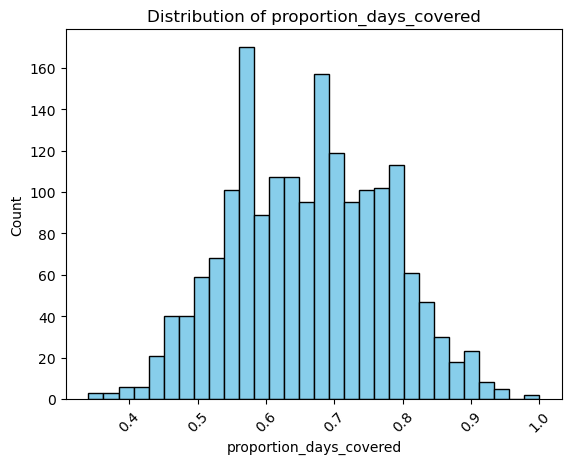

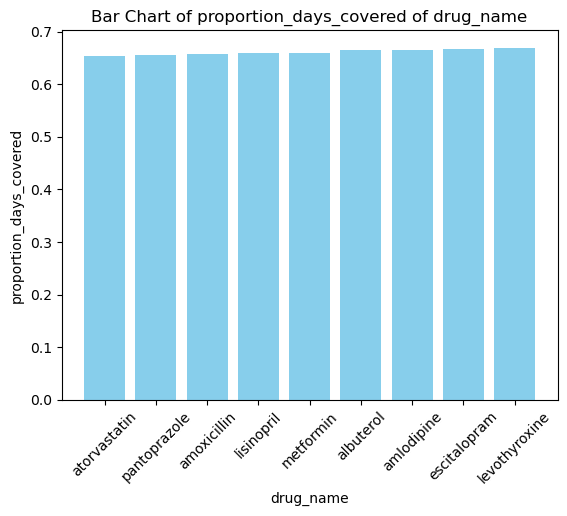

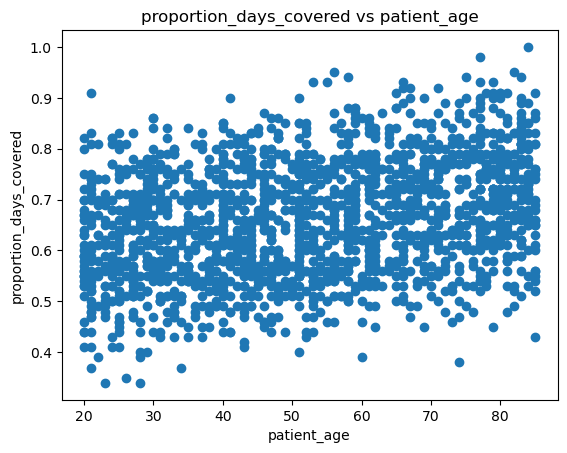

In [8]:
# Load
dataset = PharmaDataset("data/raw/prescriptions_large_raw.csv")

# Clean and save
dataset.clean()
dataset.save("data/processed/prescriptions_large_cleaned.csv")

# Visualize
dataset.hist("proportion_days_covered").show()
dataset.bar("drug_name", "proportion_days_covered").show()
dataset.scatter("patient_age", "proportion_days_covered").show()

# Exploratory Data Analysis
Explore patient summary statistics

In [9]:
# Summarize a single patient
patient = dataset.get_patient("P007")
print(patient.summary())

# Summarize all patients
patient_ids = dataset.get_df()["patient_id"].unique()

summaries = []
for pid in patient_ids:
    summaries.append(dataset.get_patient(pid).summary())

summary_df = pd.DataFrame(summaries)
print(summary_df)

{'patient_id': 'P007', 'total_fills': 2, 'avg_copay': np.float64(13.0), 'avg_days_supply': np.float64(75.0), 'pdc': np.float64(0.615), 'adherent': np.False_}
    patient_id  total_fills  avg_copay  avg_days_supply     pdc  adherent
0         P001            4    14.4700             60.0  0.6175     False
1         P002            5    14.0520             90.0  0.6740     False
2         P003            2    19.8950            105.0  0.4700     False
3         P004            4    14.0700             67.5  0.6675     False
4         P005            4    10.2800             90.0  0.7625      True
..         ...          ...        ...              ...     ...       ...
495       P496            4    15.8675             90.0  0.6000     False
496       P497            4    14.8600             67.5  0.6950     False
497       P498            5    17.2360             66.0  0.5800     False
498       P499            2    10.5800             60.0  0.6600     False
499       P500            5 

# Train a Linear Model

In [10]:
linear_trainer = ModelTrainer(
    df=dataset.get_df(),
    target="proportion_days_covered",
    features=["patient_age", "sex", "days_supply", "copay_amount", "drug_name", "pharmacy_name"]
)

linear_model, linear_metrics = linear_trainer.train_linear()
print(linear_metrics)

{'mse': 0.003712499104530776, 'mae': 0.0489934050318361, 'r2': 0.6862823280112975}


# Train a Logistic Model

In [12]:
logistic_trainer = ModelTrainer(
    df=dataset.get_df(),
    target="adherence_flag",
    features=["patient_age", "sex", "days_supply", "copay_amount", "drug_name", "pharmacy_name"]
)

logistic_model, logistic_metrics = logistic_trainer.train_logistic()
print(logistic_metrics)

{'accuracy': 0.8388888888888889, 'precision': 0.6989247311827957, 'recall': 0.6842105263157895, 'roc_auc': 0.8939424031777556}


Test out various features and interpret the results

Which features are most predictive of patient adherence? 

Given your domain expertise, justify does this make sense?

In [15]:
# Compare feature subjects
feature_sets = {
    "all":         ["patient_age", "sex", "days_supply", "copay_amount", "drug_name", "pharmacy_name"],
    "demographic": ["patient_age", "sex"],
    "clinical":    ["days_supply", "drug_name"],
    "financial":   ["copay_amount", "pharmacy_name"],
}

for name, features in feature_sets.items():
    trainer = ModelTrainer(df=dataset.get_df(), target="adherence_flag", features=features)
    _, metrics = trainer.train_logistic()
    print(f"{name:15s} → accuracy={metrics['accuracy']:.3f}, roc_auc={metrics['roc_auc']:.3f}")

all             → accuracy=0.839, roc_auc=0.894
demographic     → accuracy=0.736, roc_auc=0.663
clinical        → accuracy=0.736, roc_auc=0.486
financial       → accuracy=0.797, roc_auc=0.849


In [16]:
# Extract feature importances from the best model
preprocessor = logistic_trainer.model.named_steps["preprocessor"]
feature_names = preprocessor.get_feature_names_out()
coefficients = logistic_trainer.model.named_steps["classifer"].coef_[0]

importance_df = pd.DataFrame({
    "feature": feature_names,
    "coefficient": coefficients
}).sort_values("coefficient", key=abs, ascending=False)

print(importance_df.head(10))

                        feature  coefficient
9   cat__drug_name_escitalopram    -0.482982
2             num__copay_amount    -0.429294
12     cat__drug_name_metformin     0.274540
6     cat__drug_name_amlodipine     0.182275
13  cat__drug_name_pantoprazole     0.182221
7    cat__drug_name_amoxicillin    -0.181870
11    cat__drug_name_lisinopril     0.159853
3               cat__sex_female    -0.112084
4                 cat__sex_male     0.105247
14       cat__pharmacy_name_cvs    -0.102363


Expected clinical interpretation:
- days_supply — positive coefficient expected: longer fills → better adherence (fewer gaps)
- copay_amount — negative coefficient expected: higher out-of-pocket cost → financial barrier to refilling
- drug_name — some drugs (e.g. chronic disease like metformin) should show higher adherence than short-course antibiotics like amoxicillin
- patient_age — older patients tend to be more adherent (managing chronic conditions)
- pharmacy_name / sex — likely weak predictors